In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('housing.csv')

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df['rooms_per_household'] = df['total_rooms'] / df['households']

df['median_house_value'] = df['median_house_value'] / 1000

df = df[df['median_house_value'] < 500]

df = pd.get_dummies(df, columns=['ocean_proximity'])

In [3]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
reg.fit(X_train, y_train)
reg_pred = reg.predict(X_test)

reg.score(X_train, y_train)
reg_score = round(reg.score(X_test, y_test) * 100, 2)
reg_score

61.28

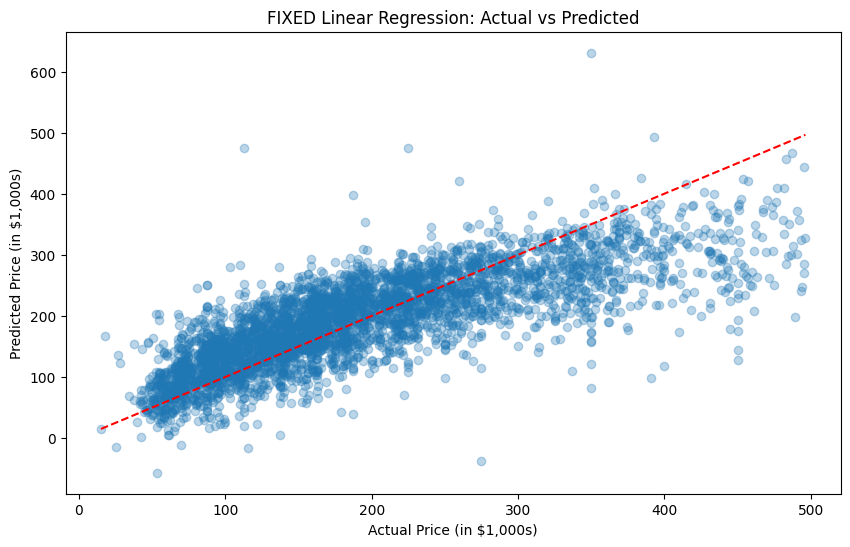

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, reg_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price (in $1,000s)')
plt.ylabel('Predicted Price (in $1,000s)')
plt.title('FIXED Linear Regression: Actual vs Predicted')
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

forest = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor())
])

forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)

forest_score = round(forest.score(X_test, y_test) * 100, 2)
forest_score

79.13

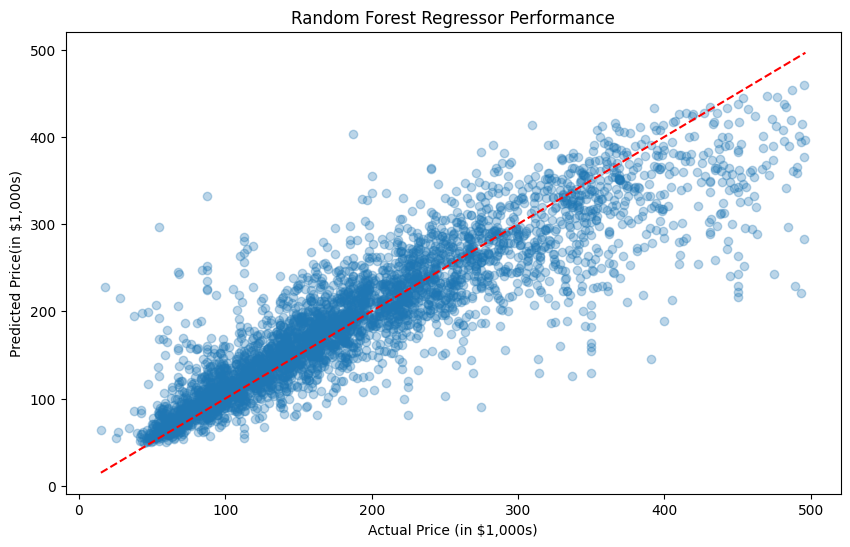

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, forest_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price (in $1,000s)')
plt.ylabel('Predicted Price(in $1,000s)')
plt.title('Random Forest Regressor Performance')
plt.show()